##Etape1:Télécharger Fashion-MNIST

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import os
import urllib.request

os.makedirs("../data", exist_ok=True)

url_train_images = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz"
url_train_labels = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz"
url_test_images = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-images-idx3-ubyte.gz"
url_test_labels = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-labels-idx1-ubyte.gz"

urllib.request.urlretrieve(url_train_images, "../data/train-images-idx3-ubyte.gz")
urllib.request.urlretrieve(url_train_labels, "../data/train-labels-idx1-ubyte.gz")
urllib.request.urlretrieve(url_test_images, "../data/t10k-images-idx3-ubyte.gz")
urllib.request.urlretrieve(url_test_labels, "../data/t10k-labels-idx1-ubyte.gz")

print("Dataset téléchargé")

Dataset téléchargé


#Etape 2:Chargement des image et label 

In [3]:
import gzip
import numpy as np

def load_images(path):
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return data

X_train = load_images("../data/train-images-idx3-ubyte.gz")
y_train = load_labels("../data/train-labels-idx1-ubyte.gz")

X_test = load_images("../data/t10k-images-idx3-ubyte.gz")
y_test = load_labels("../data/t10k-labels-idx1-ubyte.gz")

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

X_train : (60000, 28, 28)
y_train : (60000,)
X_test  : (10000, 28, 28)
y_test  : (10000,)


##visualisation des image avant leur regularisation

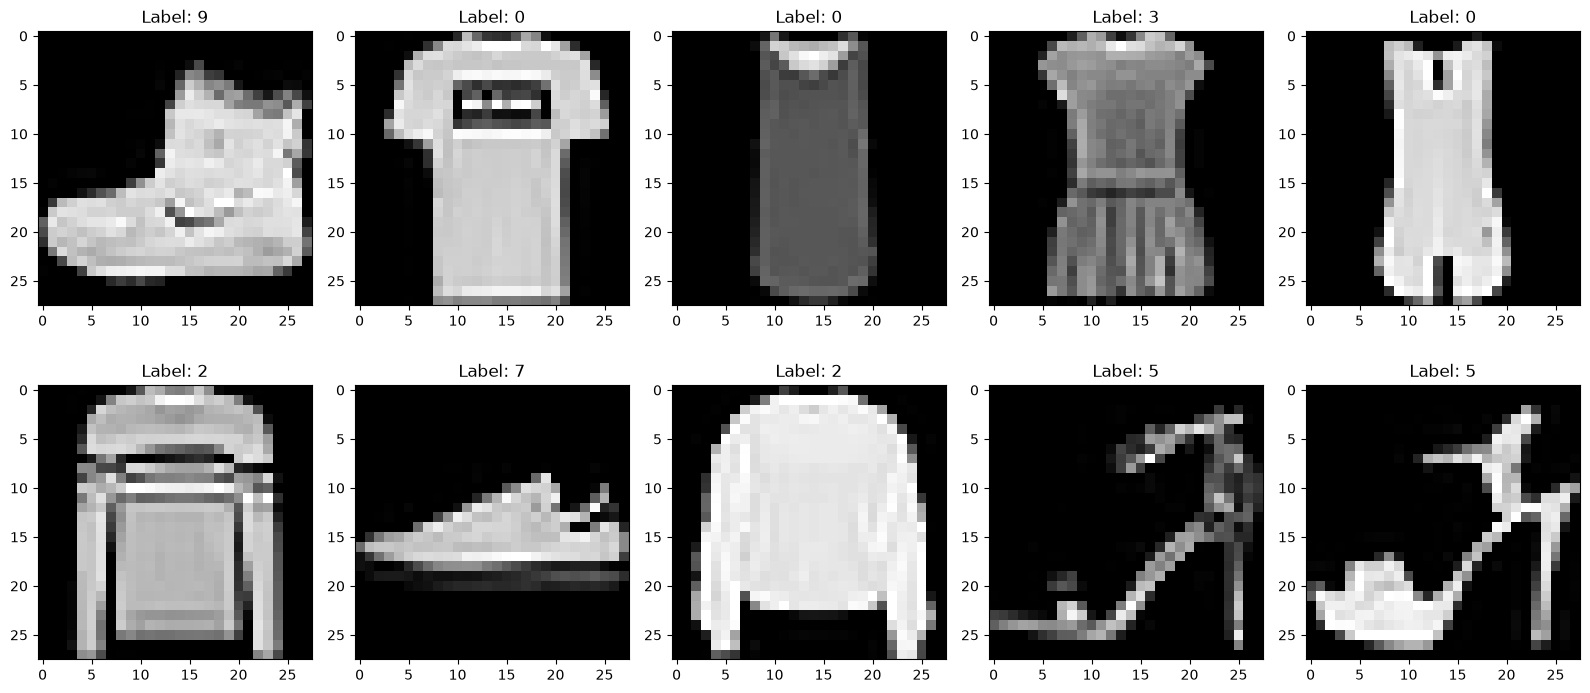

In [4]:
plt.figure(figsize=(16,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.tight_layout()
plt.show()

##Etape 4: Comprendre les donner avant la creation du reseau

In [5]:
print(X_train[0].shape)
print(X_train[0].min())
print(X_train[0].max())
print(X_train[0])

(28, 28)
0
255
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1

##Etape 5: Normalisation


In [6]:
#Normalisation
X_train = X_train / 255
X_test = X_test / 255
print(X_train.min())
print(X_train.max())

0.0
1.0


##Etape6:Reshape et transposition

In [7]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Transposition
X_train = X_train.T
X_test = X_test.T

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (784, 60000)
X_test  : (784, 10000)


In [8]:
y_train_binary = (y_train == 0).astype(int)
y_test_binary = (y_test == 0).astype(int)

y_train_binary = y_train_binary.reshape(1, -1)
y_test_binary = y_test_binary.reshape(1, -1)

print("X_train :", X_train.shape)
print("y_train :", y_train_binary.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test_binary.shape)

X_train : (784, 60000)
y_train : (1, 60000)
X_test : (784, 10000)
y_test : (1, 10000)


##Etape7:Creation du reseau de neurone

In [9]:
#fonction d'initialisation
import numpy as np


def initialisation(dimentions):

    parametres = {}

    for c in range(1, len(dimentions)):

        parametres['w' + str(c)] = np.random.randn(
            dimentions[c],
            dimentions[c-1]
        )

        parametres['b' + str(c)] = np.random.randn(
            dimentions[c],
            1
        )

    return parametres

#fonction du model(forward_propagation)
def forwar_propagation(X, parametres):

    activations = {'A0': X}

    C = len(parametres) // 2

    for c in range(1, C + 1):

        z = (
            parametres['w' + str(c)].dot(
                activations['A' + str(c-1)]
            )
            + parametres['b' + str(c)]
        )

        activations['A' + str(c)] = 1 / (1 + np.exp(-z))

    return activations


#Fonction cout
def log_loss(y, activations):

    m = y.shape[1]

    A = activations['A' + str(len(activations) - 1)]

    epsilon = 1e-15

    A = np.clip(A, epsilon, 1 - epsilon)

    loss = -(1/m) * np.sum(
        y * np.log(A) +
        (1-y) * np.log(1-A)
    )

    return loss


#fonction de calcule de gradient(back_propagation)
def back_propagation(y, parametres, activations):

    gradient = {}

    C = len(parametres) // 2

    m = y.shape[1]

    dz = activations['A' + str(C)] - y

    for i in reversed(range(1, C + 1)):

        gradient['dw' + str(i)] = (
            1/m
        ) * np.dot(
            dz,
            activations['A' + str(i-1)].T
        )

        gradient['db' + str(i)] = (
            1/m
        ) * np.sum(
            dz,
            axis=1,
            keepdims=True
        )

        dz = (
            parametres['w' + str(i)].T.dot(dz)
            * activations['A' + str(i-1)]
            * (1 - activations['A' + str(i-1)])
        )

    return gradient


#mise a joure des parametre
def update(parametres, gradient, learning_rate):

    C = len(parametres) // 2

    for c in range(1, C + 1):

        parametres['w' + str(c)] = (
            parametres['w' + str(c)]
            - learning_rate * gradient['dw' + str(c)]
        )

        parametres['b' + str(c)] = (
            parametres['b' + str(c)]
            - learning_rate * gradient['db' + str(c)]
        )

    return parametres


##Fonction du reseau de neurone

In [10]:
def deep_neurone(
    x,
    y,
    x_test,
    y_test,
    hiden_layer=(32, 32, 32),
    learning_rate=0.1,
    iter=1000
):

    dimentions = list(hiden_layer)

    dimentions.insert(0, x.shape[0])

    dimentions.append(y.shape[0])

    parametres = initialisation(dimentions)

    loss_train = []
    loss_test = []

    accuracy_train = []
    accuracy_test = []

    for i in range(iter):

        # =========================
        # ENTRAINEMENT
        # =========================

        activations = forwar_propagation(
            x,
            parametres
        )

        current_loss_train = log_loss(
            y,
            activations
        )

        A_train = activations[
            'A' + str(len(parametres) // 2)
        ]

        y_pred_train = (A_train >= 0.5).astype(int)

        current_accuracy_train = np.mean(
            y_pred_train == y
        )

        # =========================
        # TEST
        # =========================

        activations_test = forwar_propagation(
            x_test,
            parametres
        )

        current_loss_test = log_loss(
            y_test,
            activations_test
        )

        A_test = activations_test[
            'A' + str(len(parametres) // 2)
        ]

        y_pred_test = (A_test >= 0.5).astype(int)

        current_accuracy_test = np.mean(
            y_pred_test == y_test
        )

        # =========================
        # ENREGISTREMENT
        # =========================

        loss_train.append(current_loss_train)
        loss_test.append(current_loss_test)

        accuracy_train.append(current_accuracy_train)
        accuracy_test.append(current_accuracy_test)

        # =========================
        # BACKPROPAGATION
        # =========================

        gradient = back_propagation(
            y,
            parametres,
            activations
        )

        # =========================
        # MISE A JOUR
        # =========================

        parametres = update(
            parametres,
            gradient,
            learning_rate
        )

        # =========================
        # AFFICHAGE
        # =========================

        if i % 100 == 0:

            print(
                f"Iteration {i} | "
                f"Loss train : {current_loss_train:.4f} | "
                f"Loss test : {current_loss_test:.4f} | "
                f"Accuracy train : {current_accuracy_train:.4f} | "
                f"Accuracy test : {current_accuracy_test:.4f}"
            )

    # =========================
    # COURBES
    # =========================

    plt.figure(figsize=(14, 5))

    # Loss
    plt.subplot(1, 2, 1)

    plt.plot(
        loss_train,
        label="Loss entraînement"
    )

    plt.plot(
        loss_test,
        label="Loss test"
    )

    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.title("Évolution du Loss")

    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)

    plt.plot(
        accuracy_train,
        label="Accuracy entraînement"
    )

    plt.plot(
        accuracy_test,
        label="Accuracy test"
    )

    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.title("Évolution de l'Accuracy")

    plt.legend()

    plt.tight_layout()
    plt.savefig(
    "../results/figures/courbes_apprentissage.png",
    dpi=300,
    bbox_inches="tight"
)

    plt.show()

    return parametres, loss_train, loss_test, accuracy_train, accuracy_test

#Etape8:Entrainement du model

Iteration 0 | Loss train : 3.4871 | Loss test : 3.4929 | Accuracy train : 0.1070 | Accuracy test : 0.1000


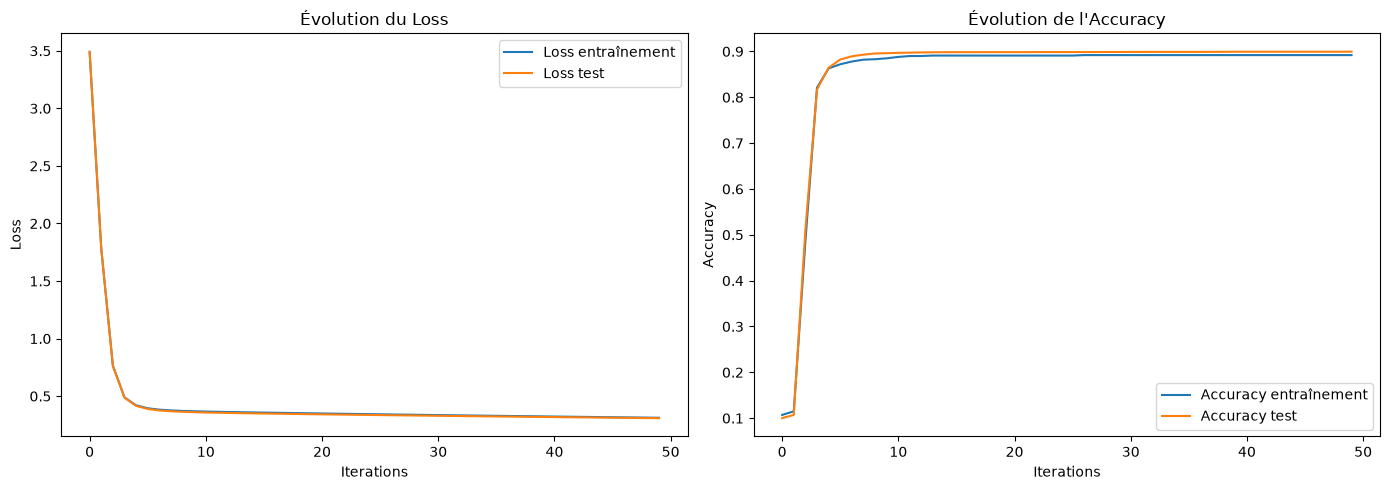

In [11]:
X_train_small = X_train[:, :1000]
y_train_small = y_train_binary[:, :1000]

parametres, loss_train, loss_test, accuracy_train, accuracy_test = deep_neurone(
    X_train_small,
    y_train_small,
    X_test,
    y_test_binary,
    hiden_layer=(32, 32, 32),
    learning_rate=0.1,
    iter=50
)